In [3]:
import numpy as np
import scipy.constants as cte
import numpy.linalg as lin
import matplotlib.pyplot as plt
import bibfunciones as bf

## Elaborado por Alexis Gael Hilario Velázquez

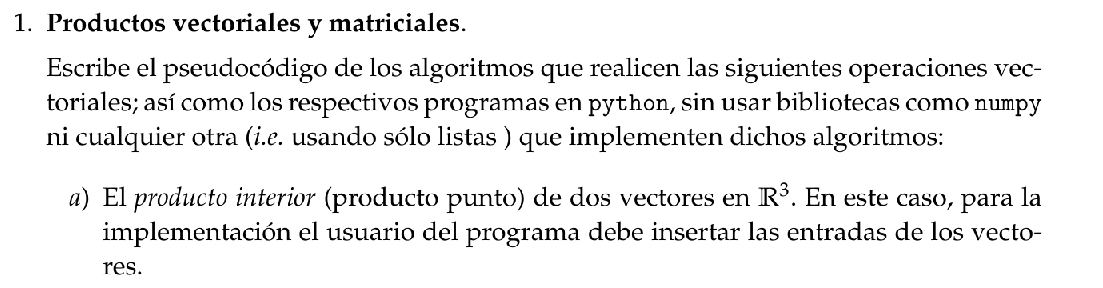

In [2]:
def prodpuntoR3():
    "Me produce el producto punto para R³, donde el usuario introduce las componentes de cada vector"
    
    a1 = float(input('dame la primer componente de tu primer vector')) #Pedimos con un input que el usuario introduzca las componentes 
    a2 = float(input('dame la segunda componente de tu primer vector')) #y convertimos en objeto flotante
    a3 = float(input('dame la tercera componente de tu primer vector'))
    b1 = float(input('dame la primer componente de tu segundo vector'))
    b2 = float(input('dame la segunda componente de tu segundo vector'))
    b3 = float(input('dame la tercera componente de tu segundo vector'))
    punto = 0 #definimos el valor del producto punto inicial en 0

    A = [a1,a2,a3] #creamos las listas con las componentes
    B = [b1,b2,b3]
    
    for i in range(len(A)): #creamos un for que nos multiplique entradas de las listas 
        punto += A[i]*B[i] #punto guarda la suma de cada componente
    
    return punto
        

In [3]:
prodpuntoR3()

dame la primer componente de tu primer vector 1
dame la segunda componente de tu primer vector 1
dame la tercera componente de tu primer vector 1
dame la primer componente de tu segundo vector 1
dame la segunda componente de tu segundo vector 1
dame la tercera componente de tu segundo vector 1


3.0

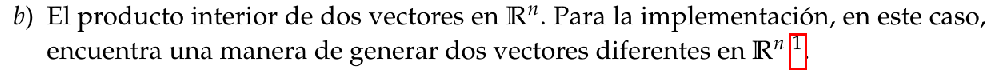


In [3]:
def prodpunto(L,P):
    punto = 0
    if (len(L) != len(P)): 
        punto = print("No se puede realizar un producto punto entre 2 listas de diferente tamaño")
    else:
        for i in range(len(L)):
            punto += L[i]*P[i]
    return punto

In [4]:
def generadordevectores(n):
    v = np.random.randint(-100, 100, size=n)
    return v

In [5]:
v1 = generadordevectores(10)


In [6]:
v2 = generadordevectores(10)

In [7]:
prodpunto(v1,v2)

np.int64(2850)

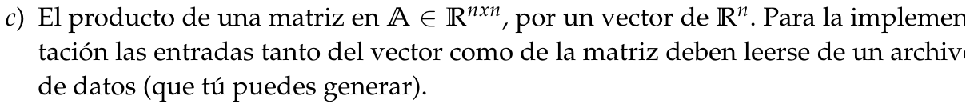


In [8]:
def generadortxt(txt):
    M = np.loadtxt(txt)
    return M

In [9]:
def Matrizporvector(txt,txt1):
    "La primera entrada debe entrar el archivo de texto de la matriz y el segundo se asigna al vector"
    M = generadortxt(txt)
    v = generador(txt1) #genero mi vector y matriz con archivos de texto
    nuevo = [] #defino un vector nuevo
    for i in range(len(M[:,0])): 
        a = prodpunto(M[i],v) #aplicamos el producto punto entre cada fila de la matriz por el vector
        nuevo.append(a) #agrega a la entrada de mi nuevo vector
    return nuevo 

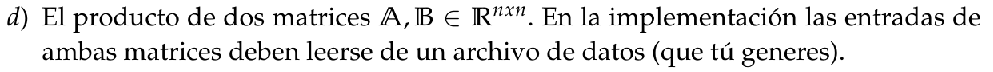

In [10]:
def MxM (txt1,txt2):
    m1 = generadortxt(txt1) 
    m2 = generadortxt(txt2)#utilizamos nuestro generador de arreglos txt para nuestras dos matrices
    new = [] #definimos una lista vacía para nuestra nueva matriz
    for i in range(len(m1)): 
        auxiliar = [] #definimos una lista auxiliar para guardar la lista de nuestros coeficientes
        for j in range(len(m2[0])): 
            entrada = prodpunto(m1[i],m2[:,j]) #la entrada es el producto punto de la fila i de la matriz 1 por la columna j de la matriz 2
            auxiliar.append(entrada) #guardamos en auxiliar
        new.append(auxiliar) #auxiliar en new, dado que la matriz es una lista de listas.
    return new 

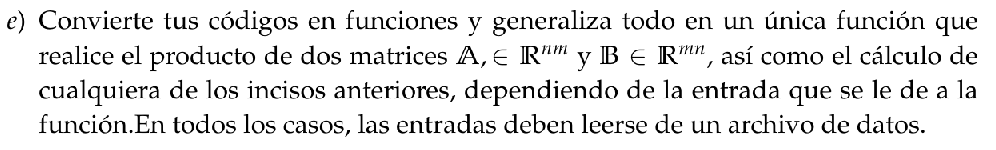

In [11]:
def productosRmn(txt1,txt2):
    m1 = generadortxt(txt1)
    m2 = generadortxt(txt2)
    if (len(np.shape(m1)) == len(np.shape(m2)) == 1): #si todo tiene longitud uno el valor de la tupla son vectores
        resultado = prodpunto(m1,m2) #por lo tanto, tenemos que realizar producto punto
    elif len(np.shape(m1)) != len(np.shape(m2)): #si son diferentes
        if len(np.shape(m1)) == 1: #y la longitud la tupla es 1, es un vector 
            v = m1 #por lo tanto v = m1
            resultado = Matrizporvector(m2,v) #realizamos matriz por vector
        else: #si no, entonces m2 es el vector
            v = m2 
            resultado = Matrizporvector(m1,v)
    elif (len(np.shape(m1)) == len(np.shape(m2)) == 2):#si ambos son iguales a 2, ambos son matrices
        resultado = MxM(m1,m2) #aplicamos multiplicación de matrices

    return resultado #siempre regresamos el resultado
        

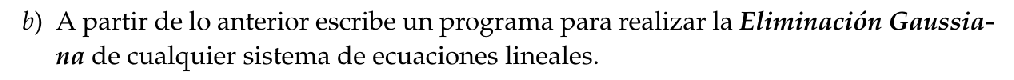


In [12]:
M = (np.array([[2.0,1.0,4.0,1.0],[3.0,4.0,-1.0,-1.0],[1.0,-4.0,1.0,5.0],[2.0, -2.0, 1.0, 3.0]]))
v= np.array([-4.0,3.0,9.0,7.0])

In [16]:
def Pivote(Mz,x): #defino a pivote 
    "Realiza un pivoteo de la Matriz Mz en el reglón x y si no es necesario realizar pivoteo dejan igual la matriz Mz "
    a = Mz[x][x] #obtenemos el valor
    N = len(Mz) #N es el tamaño de la matriz (al tamaño de su reglón)
    if a == 0: #si es a = 0
        for i in range(x+1,N): #creamos un for que verifica las entras i en x+1 y N
            if Mz[i][x] != 0: #solo si es distinto de cero se intercambian el reglon x por el i
                Mz[[i, x]] = Mz[[x, i]]
                break
    return Mz #en ambos casos regresamos Mz
print(M)
print(Pivote(M,0))

[[ 2.  1.  4.  1.]
 [ 3.  4. -1. -1.]
 [ 1. -4.  1.  5.]
 [ 2. -2.  1.  3.]]
[[ 2.  1.  4.  1.]
 [ 3.  4. -1. -1.]
 [ 1. -4.  1.  5.]
 [ 2. -2.  1.  3.]]


In [1]:
#eliminación Gaussiana de una matriz de sistema de ecuaciones M y un vector de resultados v
def ElimGauss(A,vec):
    'Realiza el método de Eliminación Gaussiana para la matriz A y vec, el vector que completa la igualdad, y además realiza la sustitución inversa'
    'de forma inmediata para obtener la solución al sistema de ecuaciones'
    N = len(vec) 
    for i in range(N): #realiza la eliminación en todo el rango
        A = Pivote(A,i) #A es igual al pivote para evitar terminos 0
        c = float(A[i][i]) #lo volvemos flotante
        A[i] = A[i]/c #aplicamos para restar el renglón i y aseguramos que A[i][i]=1
        vec[i] = vec[i]/c #se lo aplicamos igual a la entrada i del vector
        for j in range(i+1,N):
            b = A[j][i] #obtenemos los factores de multiplicación para que la resta sea cero para los valores de las columnas j de i++1 hasta N
            A[j] = A[j] - b*A[i] #restamos
            vec[j] = vec[j] - b*vec[i] #tambien lo hacemos al vector
     
    sol = np.zeros(N) #defino un arreglo en 0
    for i in range(N-1, -1, -1): #creamos un for que intere de atrás hacia delante
        sol[i] = vec[i] #todas las soluciones tienen el termino vec[i]
        for j in range(i+1, N):
            sol[i] -= A[i][j] * sol[j] #y restamos los valores que quedan en la ecuación por las soluciones j anteriores a i+1
    return sol #regresa la solución

In [26]:
ElimGauss(M,v)

array([ 2., -1., -2.,  1.])

### Hamiltoniano
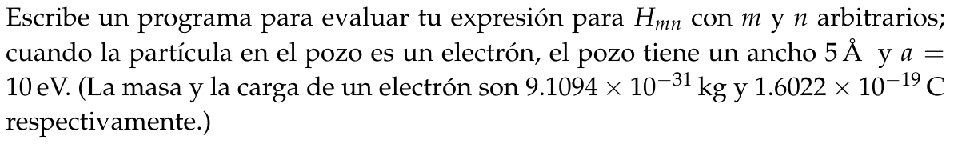

In [6]:
def Hmn(m,n): #realiza la obtención de la matriz asociado al hamiltiniano con V = a*x/L, con reglón m y columna n
    
    if m == n: 
        E = (6.242e+18)*(1/(2*cte.m_e))*(cte.hbar*np.pi*n/5e-10)**2 + 10/2
    else:
        if (m+n)%2 == 0:
            E = 0
        else:
            E = - (8*10)/(np.pi)**2 * m*n/(m**2-n**2)**2
    return E #los casos están en un pdf

In [7]:
#Matriz de 10x10

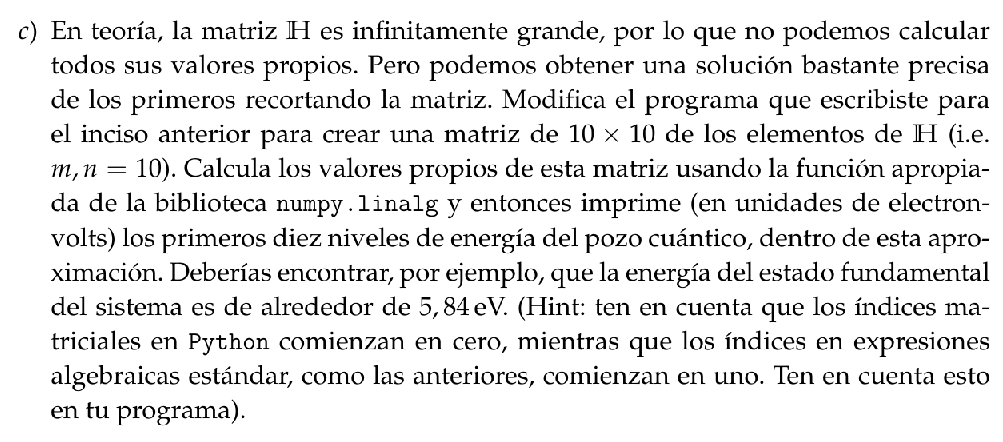

In [8]:
H = [] #para crear la matriz H. realice una lista H vacia
for i in range(1,11): #realice un for en i que son las filas
    hi = [Hmn(i,j) for j in range(1,11)] #cree listas hi con los valores Hmn donde cambian los arrglos
    H.append(hi) #los agregamos a H
H = np.array(H) #convertimos en arreglo para obtener eigenvalores con la biblioteca linalg de numpy

In [9]:
eigenvalores10 = lin.eigvalsh(H) #guardamos los eigen valores de la matriz de 10 * 10

In [10]:
#Matriz de 100 x 100

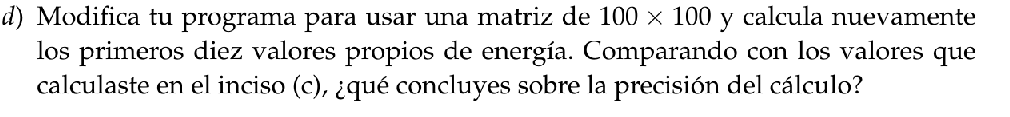

In [11]:
H = [] #aplicamos lo anterior para 100
for i in range(1,101):
    hi = [Hmn(i,j) for j in range(1,101)]
    H.append(hi)
H = np.array(H)

In [12]:
eigenvalores100 = lin.eigvalsh(H)[:10] 

In [13]:
eigenvalores10 - eigenvalores100 #comparamos la resta de los eigenvalores de ambas matrices del hamiltoniano

array([4.00610583e-07, 1.32316056e-06, 1.87085028e-06, 8.79893486e-06,
       9.11933488e-06, 5.25786825e-05, 5.18223924e-05, 6.30877697e-04,
       8.32217002e-04, 1.29612322e-01])

en la diferencia de arriba, sabemos que el eigenvalor más proximo a infinto es considerando 100 eigenfunciones,
entonces obtenemos una precisión mayor y afecta menos a los valores de las energias de valores exitados. 

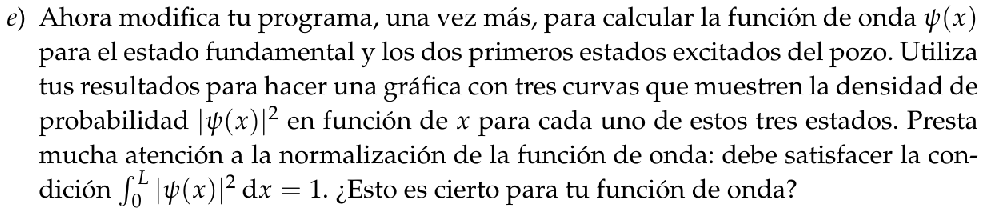

In [14]:
H10 = [] #trabajaremos con la matriz de 10 que es una buena aproximación para dichos estados 
for i in range(1,11):
    hi = [Hmn(i,j) for j in range(1,11)]
    H10.append(hi)
H10 = np.array(H10)

In [15]:
valores, vectores = lin.eigh(H10) #aplico la función eigh de la biblioteca np.linalg


La función lin.eigh nos regresa eigenvalores y eigenvectores, de nuestro hamiltoniano donde vectores[0] es el eigenvector asociado al estado fundamental y los siguientes 2 a los primeros 2 estados exitados

In [16]:
base = vectores[0] #los coeficientes de la función \psi para el estado fundamental
excitado1 = vectores[1] #los coeficientes de la función \psi para el primer estado excitado
excitado2 = vectores[2] #y el segundo

In [17]:
def fbase(x): #definimos las funciones que recordar que es \psi(x)**2 que es multiplicar por el complejo conjugado a la función
    N = 10
    f = 0
    for i in range(1,N+1):
        for j in range(1,N+1):#lo cual se expresa como una doble suma 
            f += base[j-1]*base[i-1]*np.sin(i*np.pi*x/5e-10)*np.sin(j*np.pi*x/5e-10)
    return f

Nota: la diferencia entre estados base, excitados son los coeficientes, los cuales son los vectores propios.

In [18]:
def fex1(x):
    N = 10
    f = 0
    for i in range(1,N+1):
        for j in range(1,N+1):
            f += excitado1[i-1]*np.sin(i*np.pi*x/5e-10)*excitado1[j-1]*np.sin(j*np.pi*x/5e-10)
    return f

In [19]:
def fex2(x):
    N = 10
    f = 0
    for i in range(1,N+1):
        for j in range(1,N+1):
            f += excitado2[i-1]*np.sin(i*np.pi*x/5e-10)*excitado2[j-1]*np.sin(j*np.pi*x/5e-10)
    return f

In [20]:
X = np.linspace(0,5e-10,100)#creamos un arreglo que está entre 0 y L

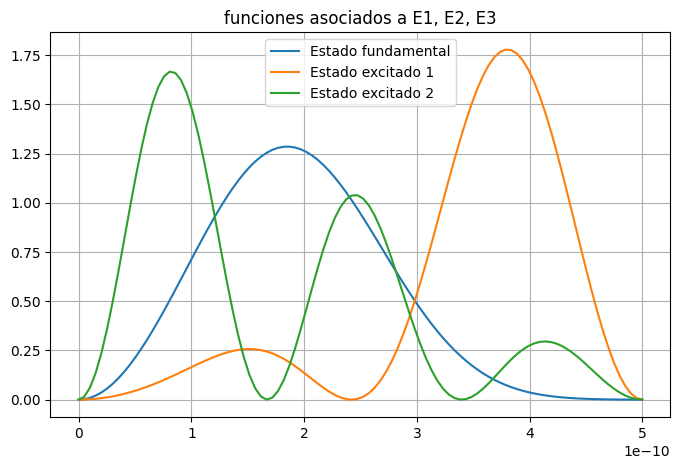

In [25]:
plt.figure(figsize=(8,5))
plt.title('funciones asociados a E1, E2, E3')
plt.plot(X,fbase(X), label = 'Estado fundamental')
plt.plot(X,fex1(X), label = 'Estado excitado 1')
plt.plot(X,fex2(X), label = 'Estado excitado 2')
plt.legend()
plt.grid()
plt.show()

Realizando integración de la función de estado fundamental tenemos que

In [26]:
L = 5e-10

In [28]:
Cn_0=bf.CuadGauss(0,L,1000,fbase)

El valor es diferente de 1 para que sea igual a 1, se realiza lo siguiente

In [30]:
def fbasen(x):
    return fbase(x)/Cn_0

In [31]:
#y para los demás valores

1.0000000000000018

In [32]:
Cn_1 = bf.CuadGauss(0,L,1000,fex1)

In [34]:
Cn_2 = bf.CuadGauss(0,L,1000,fex2)

In [35]:
def fex1n(x):
    return fex1(x)/Cn_1

In [36]:
def fex2n(x):
    return fex2(x)/Cn_2

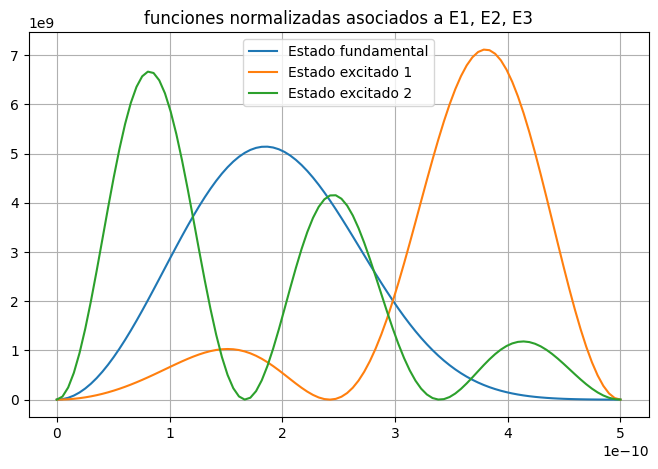

In [37]:
plt.figure(figsize=(8,5))
plt.title('funciones normalizadas asociados a E1, E2, E3')
plt.plot(X,fbasen(X), label = 'Estado fundamental')
plt.plot(X,fex1n(X), label = 'Estado excitado 1')
plt.plot(X,fex2n(X), label = 'Estado excitado 2')
plt.legend()
plt.grid()
plt.show()